# StatsForecast with synthetic data

`AutoETS` and the other StatsForecast models are fitted independently per series, so the two workflows that matter for synthetic data are different from the global-model case. This guide shows that augmenting a panel cannot change a local fit, and uses synthetic series with a known data-generating process to check that the forecasting pipeline recovers what was put into it.


StatsForecast models are fitted independently to each series and share no transferable weights. Two consequences follow, and they set up the rest of this guide.

Adding synthetic series to the panel leaves the model fitted to the observed series bit-for-bit identical — there is no pooled parameter for the extra series to influence. And because nothing is shared, fitting local models to synthetic histories transfers nothing to the observed series: there is no local-model analogue of synthetic pretraining. The section below measures both claims.

::: {.callout-tip}
## Where synthetic data does help here

Generating from a process you configured yourself gives a holdout whose truth you know, including the irreducible noise floor. That turns a forecast comparison into a pipeline check: if `AutoETS` cannot recover a clean seasonal process, the problem is the setup rather than the data.
:::


We use the classic [Box–Jenkins airline passenger series](https://search.r-project.org/R/refmans/datasets/html/AirPassengers.html). Its final 12 months are held out before `SynAugment` analyzes the training history.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive

from synforecast import SynAugment
from synforecast.generators import ETSGenerator


In [ ]:
HORIZON = 12
TARGET_ID = "AirPassengers"
data_path = Path("nbs/data/air_passengers.csv")
if not data_path.exists():
    data_path = Path("../../data/air_passengers.csv")

observed_df = pd.read_csv(data_path, parse_dates=["ds"])
train_df = observed_df.iloc[:-HORIZON].copy()
test_df = observed_df.iloc[-HORIZON:].copy()
train_df.tail()

,unique_id,ds,y
127,AirPassengers,1959-08-31,559.0
128,AirPassengers,1959-09-30,463.0
129,AirPassengers,1959-10-31,407.0
130,AirPassengers,1959-11-30,362.0
131,AirPassengers,1959-12-31,405.0


In [ ]:
augmented_train_df = SynAugment(seed=42).augment(
    train_df,
    n_augment=16,
    generator_override={TARGET_ID: "SARIMAGenerator"},
)
synthetic_history_df = augmented_train_df.loc[
    augmented_train_df["unique_id"].astype(str) != TARGET_ID
].copy()

pd.DataFrame(
    {
        "training set": ["observed only", "observed + augmented", "matched synthetic only"],
        "series": [1, augmented_train_df["unique_id"].nunique(), synthetic_history_df["unique_id"].nunique()],
    }
)

,training set,series
0,observed only,1
1,observed + augmented,17
2,matched synthetic only,16


In [ ]:
def make_forecaster() -> StatsForecast:
    return StatsForecast(
        models=[AutoETS(season_length=12)],
        freq="ME",
        n_jobs=1,
    )


def target_forecast(forecast_df: pd.DataFrame) -> pd.DataFrame:
    return forecast_df.loc[
        forecast_df["unique_id"].astype(str) == TARGET_ID,
        ["unique_id", "ds", "AutoETS"],
    ].copy()

In [ ]:
real_only = make_forecaster()
real_only.fit(train_df)
real_only_forecast = target_forecast(real_only.predict(h=HORIZON))

In [ ]:
with_augmentation = make_forecaster()
with_augmentation.fit(augmented_train_df)
augmented_forecast = target_forecast(with_augmentation.predict(h=HORIZON))

np.allclose(real_only_forecast["AutoETS"], augmented_forecast["AutoETS"])

True

Averaging forecasts from those synthetic histories would not give a usable forecast, and the reason is worth measuring rather than asserting. `SynAugment` matches each synthetic series to the **mean of the training window**, not to its final level. On a strongly trending series those are far apart, so the synthetic histories end at levels scattered around the observed endpoint.


In [ ]:
levels = synthetic_history_df.groupby("unique_id", observed=True)["y"].agg(
    window_mean="mean",
    final_year_mean=lambda values: values.tail(12).mean(),
)

pd.DataFrame(
    {
        "series": ["observed", "synthetic (16 draws)"],
        "window mean": [
            round(train_df["y"].mean(), 1),
            f"{levels['window_mean'].min():.0f} - {levels['window_mean'].max():.0f}",
        ],
        "final-year mean": [
            round(train_df["y"].tail(12).mean(), 1),
            f"{levels['final_year_mean'].min():.0f} - {levels['final_year_mean'].max():.0f}",
        ],
    }
)


,series,window mean,final-year mean
0,observed,262.5,428.3
1,synthetic (16 draws),262 - 263,191 - 506


In [ ]:
forecast_sets = {
    "Observed only": real_only_forecast,
    "Observed + synthetic panel": augmented_forecast,
}
comparison = test_df[["unique_id", "ds", "y"]].copy()
for label, forecast_df in forecast_sets.items():
    comparison = comparison.merge(
        forecast_df.rename(columns={"AutoETS": label}),
        on=["unique_id", "ds"],
        how="left",
    )

pd.DataFrame(
    {
        "workflow": list(forecast_sets),
        "MAE": [
            (comparison[label] - comparison["y"]).abs().mean()
            for label in forecast_sets
        ],
    }
)


,workflow,MAE
0,Observed only,35.612471
1,Observed + synthetic panel,35.612471


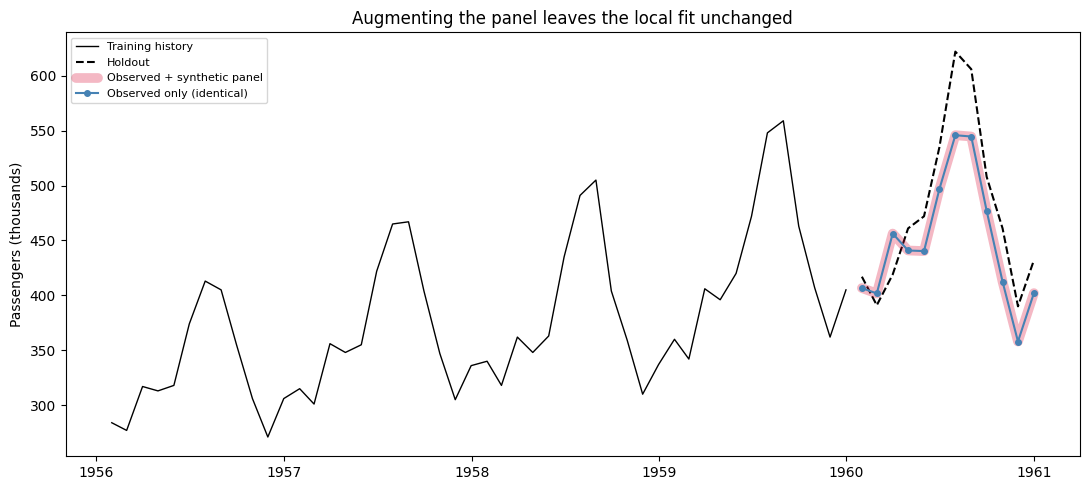

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
history = train_df.tail(48)
ax.plot(history["ds"], history["y"], color="black", linewidth=1, label="Training history")
ax.plot(test_df["ds"], test_df["y"], color="black", linestyle="--", label="Holdout")
# The two forecasts are identical, so the augmented one is drawn wide and
# translucent with the observed-only line on top of it.
ax.plot(comparison["ds"], comparison["Observed + synthetic panel"],
        color="crimson", linewidth=7, alpha=0.3, solid_capstyle="round",
        label="Observed + synthetic panel")
ax.plot(comparison["ds"], comparison["Observed only"],
        color="steelblue", linewidth=1.5, marker="o", markersize=4,
        label="Observed only (identical)")
ax.set(title="Augmenting the panel leaves the local fit unchanged",
       ylabel="Passengers (thousands)")
ax.legend(fontsize=8)
fig.tight_layout()


## Validate the pipeline on a known process

The airline series has no ground truth beyond its holdout. A generated series does: the process, its seasonal period, and its noise scale are all inputs. Below, twelve series come from an additive ETS process with a 12-period season and a fixed noise standard deviation, the last 12 points of each are held out, and `AutoETS` is scored against `SeasonalNaive` and against the generator's noise floor.


In [ ]:
NOISE_STD = 6.0
known_process = ETSGenerator(
    min_length=132,
    max_length=132,
    freq="ME",
    engine="polars",
    seasonal_period=12,
    error_type="add",
    trend_type="add",
    seasonal_type="add",
    level=300.0,
    trend=1.5,
    noise_std=NOISE_STD,
    seed=7,
)
known_panel = known_process.generate(n_series=12).to_pandas()

is_holdout = (
    known_panel.groupby("unique_id", observed=True).cumcount() >= 132 - HORIZON
)
known_train_df = known_panel.loc[~is_holdout]
known_test_df = known_panel.loc[is_holdout]

known_models = StatsForecast(
    models=[AutoETS(season_length=12), SeasonalNaive(season_length=12)],
    freq="ME",
    n_jobs=1,
)
known_models.fit(known_train_df)
known_forecast = known_models.predict(h=HORIZON).merge(
    known_test_df[["unique_id", "ds", "y"]], on=["unique_id", "ds"]
)

pd.DataFrame(
    {
        "model": ["AutoETS", "SeasonalNaive", "noise floor (generator)"],
        "MAE": [
            (known_forecast["AutoETS"] - known_forecast["y"]).abs().mean(),
            (known_forecast["SeasonalNaive"] - known_forecast["y"]).abs().mean(),
            NOISE_STD,
        ],
    }
).round(2)


,model,MAE
0,AutoETS,11.52
1,SeasonalNaive,49.54
2,noise floor (generator),6.00


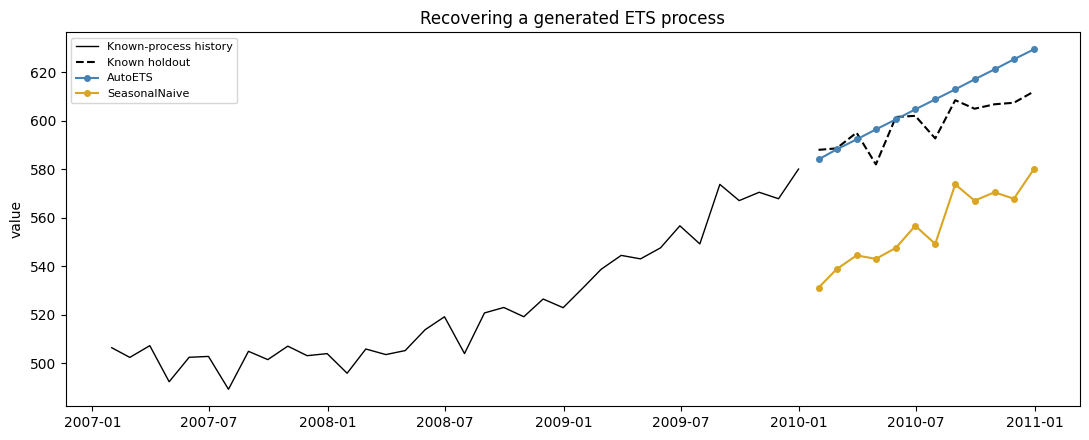

In [ ]:
example_id = known_panel["unique_id"].iloc[0]
example_history = known_train_df.loc[known_train_df["unique_id"] == example_id].tail(36)
example_holdout = known_test_df.loc[known_test_df["unique_id"] == example_id]
example_forecast = known_forecast.loc[known_forecast["unique_id"] == example_id]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(example_history["ds"], example_history["y"], color="black", linewidth=1,
        label="Known-process history")
ax.plot(example_holdout["ds"], example_holdout["y"], color="black", linestyle="--",
        label="Known holdout")
ax.plot(example_forecast["ds"], example_forecast["AutoETS"], color="steelblue",
        marker="o", markersize=4, label="AutoETS")
ax.plot(example_forecast["ds"], example_forecast["SeasonalNaive"], color="goldenrod",
        marker="o", markersize=4, label="SeasonalNaive")
ax.set(title="Recovering a generated ETS process", ylabel="value")
ax.legend(fontsize=8)
fig.tight_layout()


For local models, synthetic data is a test instrument rather than extra training signal.

- **Augmentation is inert.** The observed-only and augmented forecasts agree to floating-point precision, because `AutoETS` fits each series on its own. Panel augmentation only helps model families that pool parameters across series — see the [MLForecast](mlforecast) and [NeuralForecast](neuralforecast) guides for that case.
- **There is no local-model pretraining.** Fitting `AutoETS` to synthetic histories produces forecasts for those histories, not for the observed series. The level table above shows why aggregating them is not a shortcut: matching the window mean leaves the final-year level free, so the draws end far from the observed endpoint.
- **A known process validates the pipeline.** On data generated from a configured `ETSGenerator`, `AutoETS` lands within about twice the generator's own noise floor and well ahead of `SeasonalNaive`. Running that check before pointing a pipeline at real data separates model problems from data problems.

Synthetic panels are also useful here for simulation and stress testing: inject [anomalies](../capabilities/anomalies) or [changepoints](../capabilities/changepoints) with known positions and measure how far the fitted model moves.
